In [123]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
# Years of experience
X = np.array([1, 3, 4, 6, 7])

# Salary in thousands
y = np.array([15, 35, 45, 65, 75])

<Axes: >

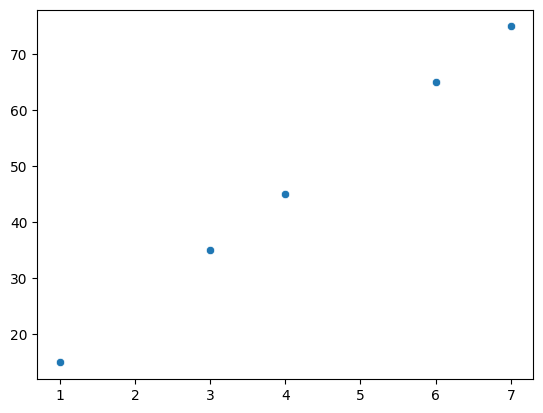

In [125]:
sns.scatterplot(x = X, y= y)

In [126]:
def make_prediction(X,y,w,b):

  m = X.shape[0]

  pred_list = np.zeros((m,))

  for i in range(m):
    pred_list[i] = w * X[i] + b

  return pred_list

[0. 0. 0. 0. 0.]


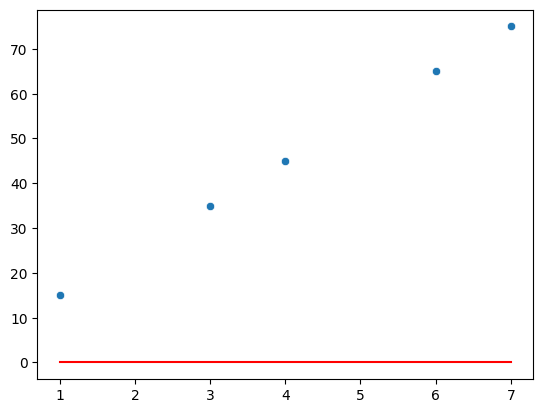

In [127]:
predictions = make_prediction(X, y, 0, 0)
print(predictions)

sns.scatterplot(x = X, y= y)
plt.plot(X, predictions, color='red')

[1. 3. 4. 6. 7.]


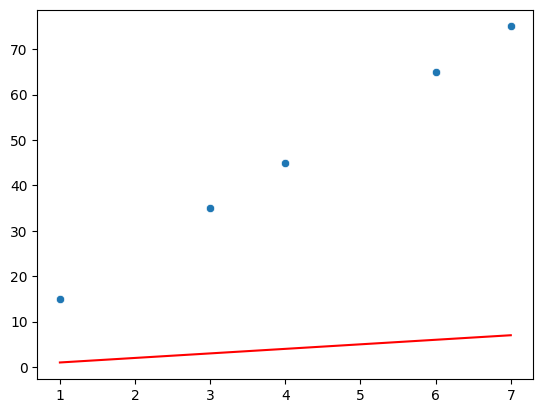

In [128]:
predictions = make_prediction(X, y, w=1, b=0)

print(predictions)

sns.scatterplot(x = X, y= y)
plt.plot(X, predictions, color='red')

[ 8. 18. 23. 33. 38.]


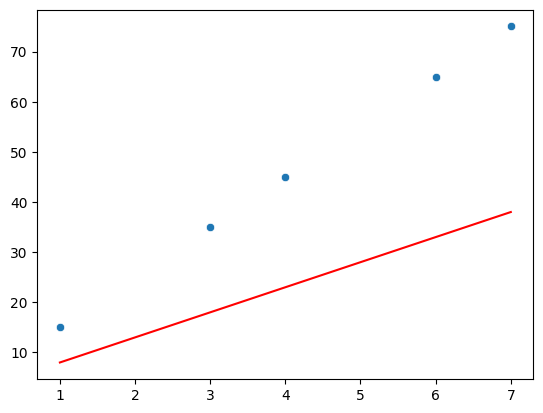

In [129]:
predictions = make_prediction(X, y, w=5, b=3)

print(predictions)

sns.scatterplot(x = X, y= y)
plt.plot(X, predictions, color='red')

[15. 35. 45. 65. 75.]


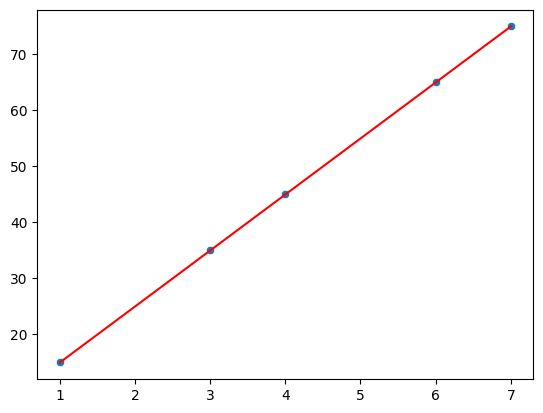

In [130]:
predictions = make_prediction(X, y, w=10, b=5)

print(predictions)

sns.scatterplot(x = X, y= y)
plt.plot(X, predictions, color='red')

In [131]:
def compute_cost(X,y,w,b):

  m = X.shape[0]

  cost = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = pow((prediction - y[i]), 2)
    cost += error

  cost = cost / (2*m)

  return cost


[0. 0. 0. 0. 0.]


Text(0.5, 1.0, 'Cost: 1332.5 for w: 0 and b: 0')

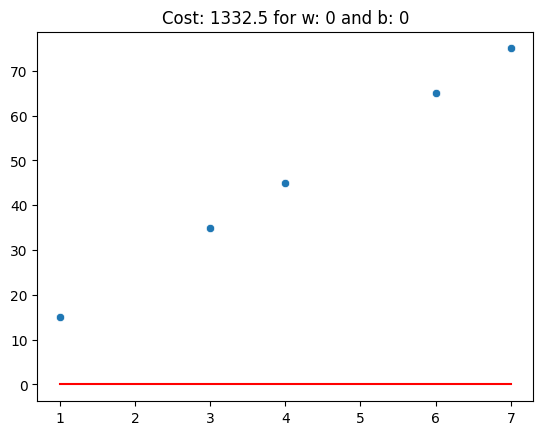

In [132]:
w = 0
b = 0

predictions = make_prediction(X, y, w, b)

print(predictions)

sns.scatterplot(x = X, y= y)
plt.plot(X, predictions, color='red')

plt.title(f'Cost: {compute_cost(X, y, w, b)} for w: {w} and b: {b}')


[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost: 0.0 for w: 10 and b: 5')

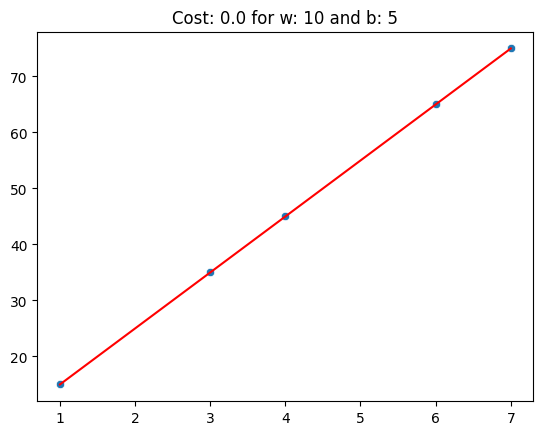

In [133]:
w = 10
b = 5

predictions = make_prediction(X, y, w, b)

print(predictions)

sns.scatterplot(x = X, y= y)
plt.plot(X, predictions, color='red')

plt.title(f'Cost: {compute_cost(X, y, w, b)} for w: {w} and b: {b}')


Text(0, 0.5, 'Cost - J(w)')

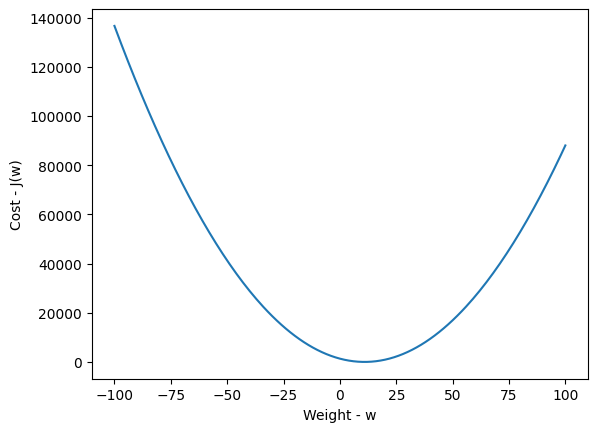

In [134]:
w = []

cost = []

for i in range(-100, 101):
  cost_i = compute_cost(X,y,w=i,b=0)
  w.append(i)
  cost.append(cost_i)

plt.plot(w,cost)
plt.xlabel('Weight - w')
plt.ylabel('Cost - J(w)')

In [135]:
def calculate_gradient(X,y,w,b):
  m = X.shape[0]

  gradient = 0.0

  dj_dw, dj_db = 0.0, 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    dj_dw += (error * X[i])
    dj_db += error

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db

In [136]:
calculate_gradient(X,y,w=3,b=0)

(np.float64(-176.4), np.float64(-34.4))

In [137]:
def gradient_descent(X,y,w_input, b_input, max_iter, aplha=0.01):
  w = w_input
  b = b_input

  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = calculate_gradient(X,y,w,b)

    w = w - aplha * dj_dw
    b = b - aplha * dj_db

    cost = compute_cost(X,y,w,b)

    cost_memo.append(cost)
    iteration.append(i)

    if i % 100 == 0:
      print(f'Iteration: {i}, w: {w:.4f}, b: {b:.4f}, dj_dw: {dj_dw:.4f}, dj_db: {dj_db:.4f}, Cost: {cost:.4f}')

  return w, b, cost_memo, iteration

In [146]:
w_final, b_final, cost_memo, iter = gradient_descent(X,y,w_input=0, b_input=0, max_iter=10000, aplha=0.01)

Iteration: 0, w: 2.4300, b: 0.4700, dj_dw: -243.0000, dj_db: -47.0000, Cost: 790.3717
Iteration: 100, w: 10.4659, b: 2.5593, dj_dw: 0.0926, dj_db: -0.4848, Cost: 0.6120
Iteration: 200, w: 10.3821, b: 2.9986, dj_dw: 0.0759, dj_db: -0.3976, Cost: 0.4115
Iteration: 300, w: 10.3133, b: 3.3588, dj_dw: 0.0622, dj_db: -0.3260, Cost: 0.2767
Iteration: 400, w: 10.2569, b: 3.6542, dj_dw: 0.0510, dj_db: -0.2673, Cost: 0.1861
Iteration: 500, w: 10.2107, b: 3.8965, dj_dw: 0.0418, dj_db: -0.2192, Cost: 0.1251
Iteration: 600, w: 10.1727, b: 4.0951, dj_dw: 0.0343, dj_db: -0.1798, Cost: 0.0841
Iteration: 700, w: 10.1416, b: 4.2580, dj_dw: 0.0281, dj_db: -0.1474, Cost: 0.0566
Iteration: 800, w: 10.1162, b: 4.3915, dj_dw: 0.0231, dj_db: -0.1209, Cost: 0.0380
Iteration: 900, w: 10.0952, b: 4.5010, dj_dw: 0.0189, dj_db: -0.0991, Cost: 0.0256
Iteration: 1000, w: 10.0781, b: 4.5909, dj_dw: 0.0155, dj_db: -0.0813, Cost: 0.0172
Iteration: 1100, w: 10.0640, b: 4.6645, dj_dw: 0.0127, dj_db: -0.0666, Cost: 0.0116

In [147]:
print(w_final,b_final)

10.00000000137122 4.999999992816854


[14.99999999 35.         45.         65.         75.        ]


Text(0.5, 1.0, 'Cost: 5.300876935637457e-18 for w: 10.0000 and b: 5.0000')

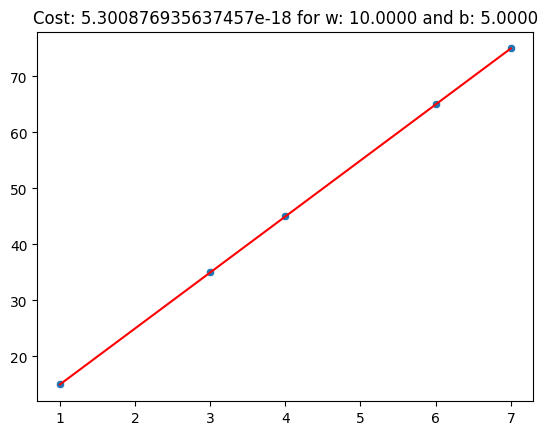

In [148]:
predictions = make_prediction(X, y, w=w_final, b=b_final)

print(predictions)

sns.scatterplot(x = X, y= y)
plt.plot(X, predictions, color='red')

plt.title(f'Cost: {compute_cost(X, y, w_final, b_final)} for w: {w_final:.4f} and b: {b_final:.4f}')

In [149]:
x = 2

prediction = w_final * x + b_final

print(prediction)

24.999999995559293


Text(0, 0.5, 'Cost')

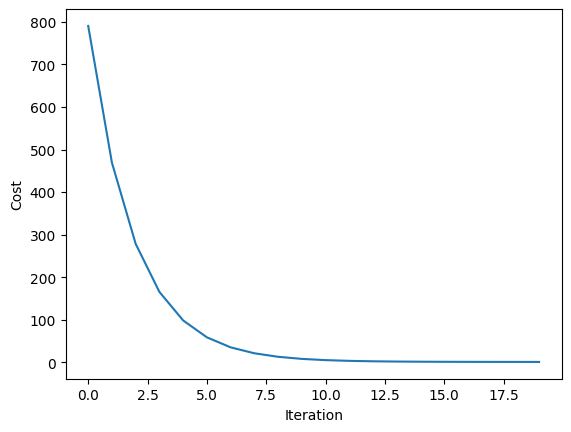

In [153]:
plt.plot(iter[:20], cost_memo[:20])
plt.xlabel('Iteration')
plt.ylabel('Cost')
#